In [123]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast
def parse_str_list(cell):
    try:
        return ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return cell
    
data_path = "/home/linhang/workbench/Earthquake_data_V2/"
area = 'Anchoragebig'
data_area_path = data_path + area + "/"
gnss_data = pd.read_csv(data_area_path + "gnss_data.csv", index_col=0, parse_dates=True, low_memory=False).map(parse_str_list)
earthquake_data = pd.read_csv(data_area_path+"earthquake_data.csv", index_col=0, parse_dates=True)

In [124]:
start_time = pd.to_datetime("2018-01-01")
end_time = pd.to_datetime("2018-12-31")
gnss_data_2019 = gnss_data[start_time:end_time]

In [125]:
gnss_data_our = gnss_data_2019.map(lambda x: np.nan if np.any(pd.isna(x)) else np.array(x[2])).T

In [126]:
def fill_nan_with_moving_median(data, window=10):
    """
    使用滑动窗口的中位数填充 NaN 值，沿时间维度操作（每个站点的时间序列）
    :param data: 输入的 DataFrame，形状为 (站点数, 时间步)
    :param window: 滑动窗口的长度
    :return: 填充后的 DataFrame，移除所有全为 NaN 的行
    """
    filled_data = data.copy()
    for station in range(data.shape[0]):  # 针对每个站点
        time_series = data.iloc[station]  # 获取该站点的时间序列
        
        # 确保时间序列的索引是整数，或适配时间戳类型的索引
        time_series = time_series.reset_index(drop=True)
        
        nan_indices = time_series[time_series.isna()].index
        for idx in nan_indices:
            # 确定窗口范围
            start = max(0, idx - window // 2)
            end = min(len(time_series), idx + window // 2 + 1)
            # 计算窗口内的中位数，忽略 NaN
            window_values = time_series[start:end].dropna()
            if len(window_values) > 0:
                median_value = window_values.median()
                time_series[idx] = median_value
        
        # 更新填充后的时间序列
        filled_data.iloc[station] = time_series.values

    # 删除所有全为 NaN 的行
    filled_data = filled_data.dropna(how='any')

    return filled_data

In [127]:
gnss_data_our = fill_nan_with_moving_median(gnss_data_our)
gnss_data_our = np.array(gnss_data_our, dtype=float)

In [128]:
gnss_data_our.shape

(141, 365)

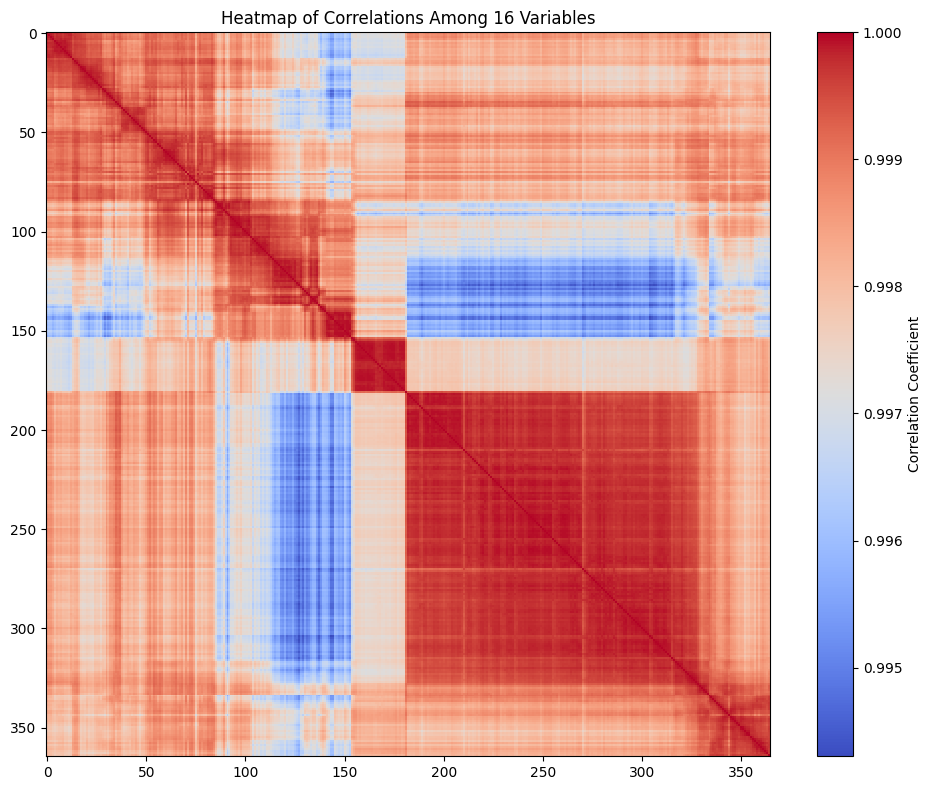

In [158]:
# Calculate the correlation matrix
correlation_matrix = np.corrcoef(gnss_data_our.T)

# Plot the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.title('Heatmap of Correlations Among 16 Variables')
plt.tight_layout()
plt.show()

In [129]:
gnss_data.shape

(8766, 223)

In [143]:
gnss_data = loadmat('workbench/workbench/Earthquake_predictor/reference_project/RSIT/GNSS_South_central_Alaska_20180101_20181231.mat')['GNSS_South_central_Alaska_20180101_20181231'].T

In [147]:
gnss_data = (gnss_data - np.nanmean(gnss_data, axis=1, keepdims=True)) / np.nanstd(gnss_data, axis=1, keepdims=True)

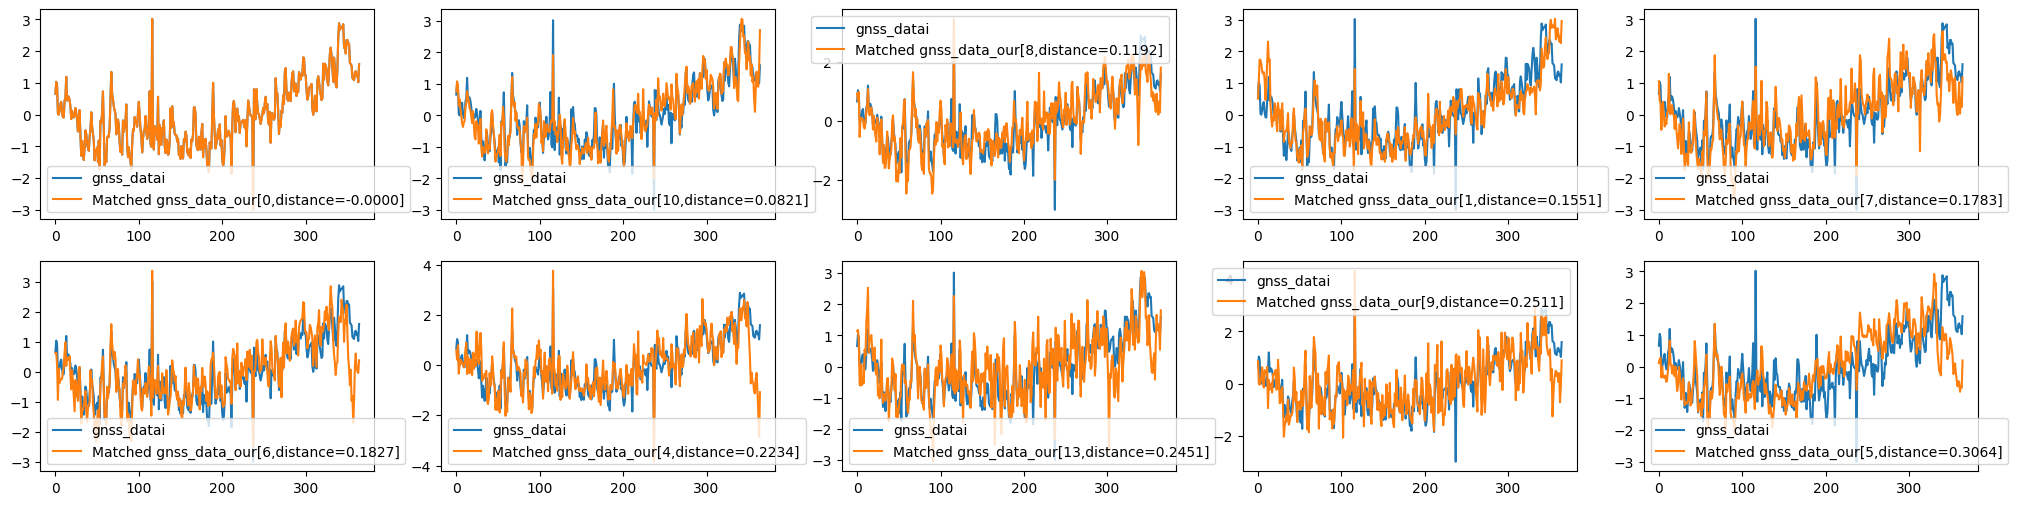

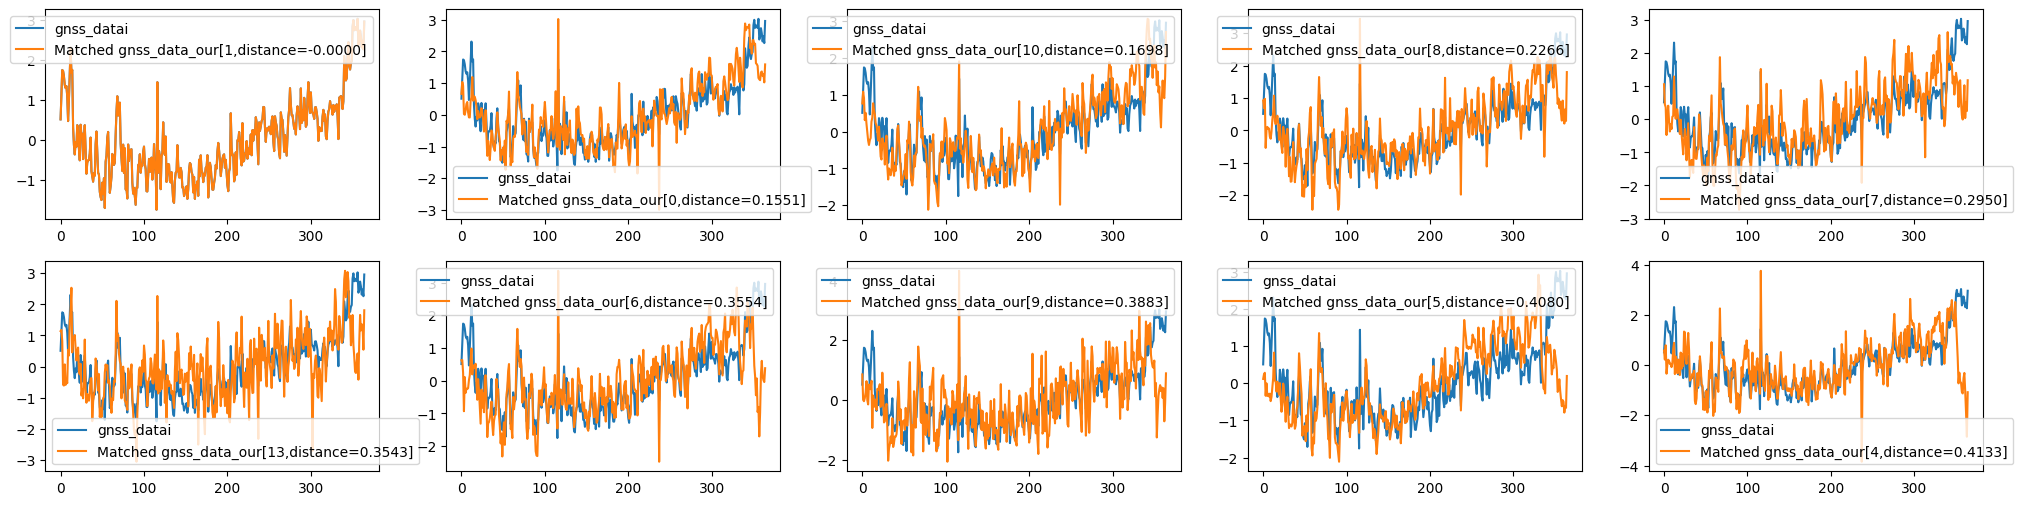

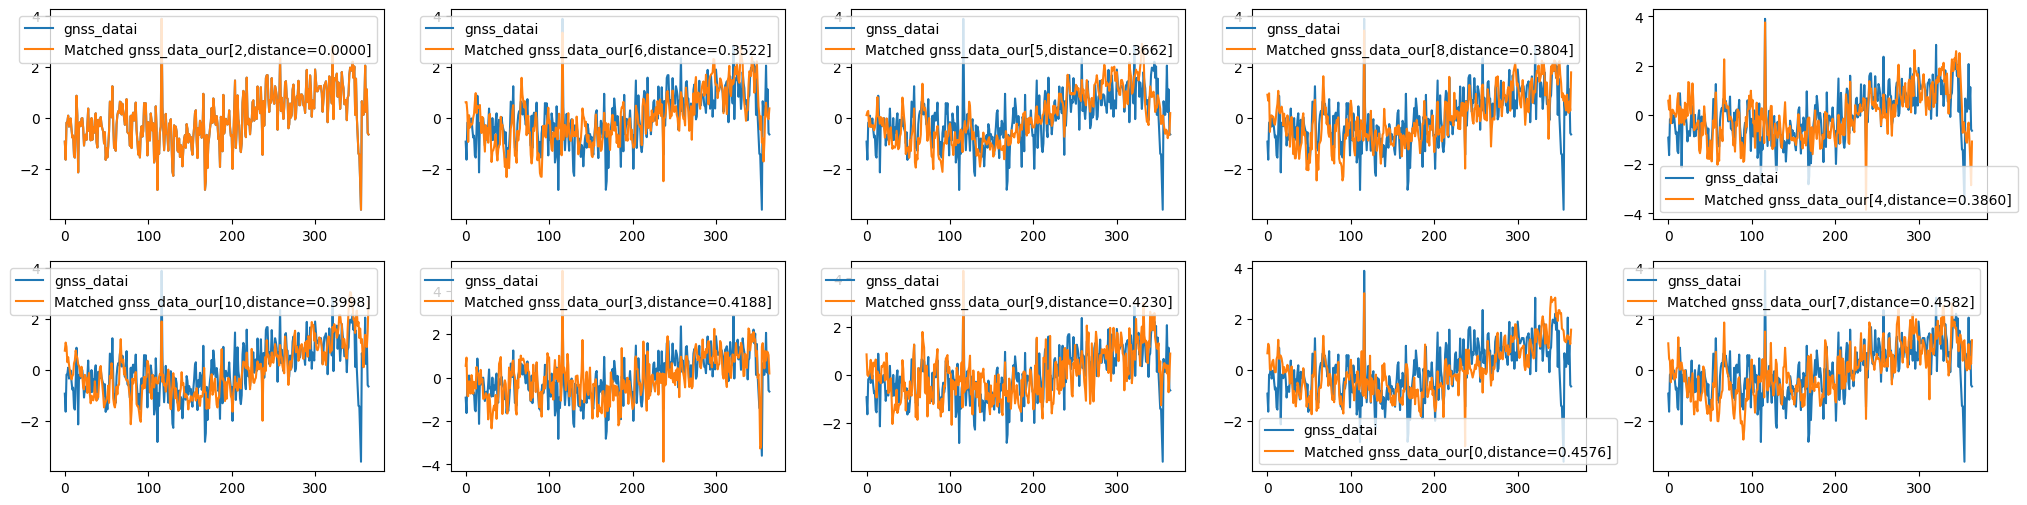

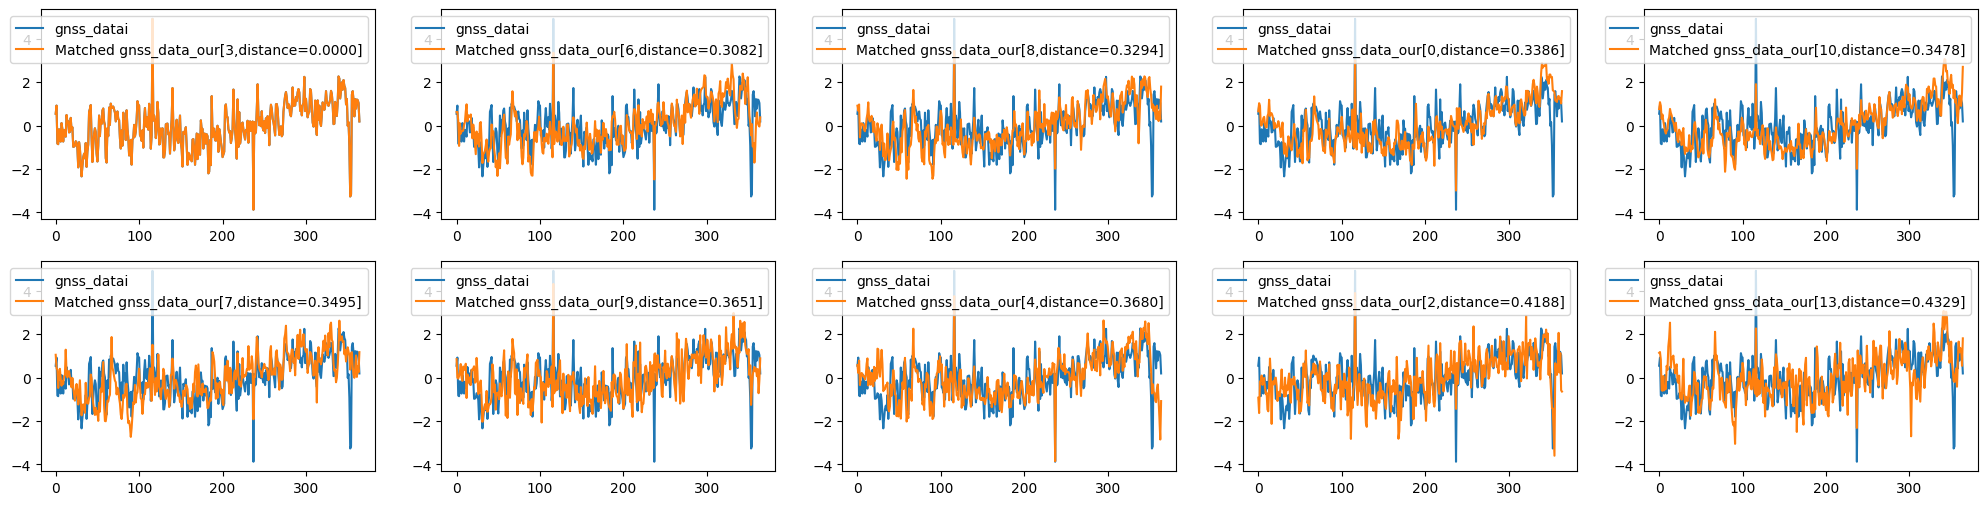

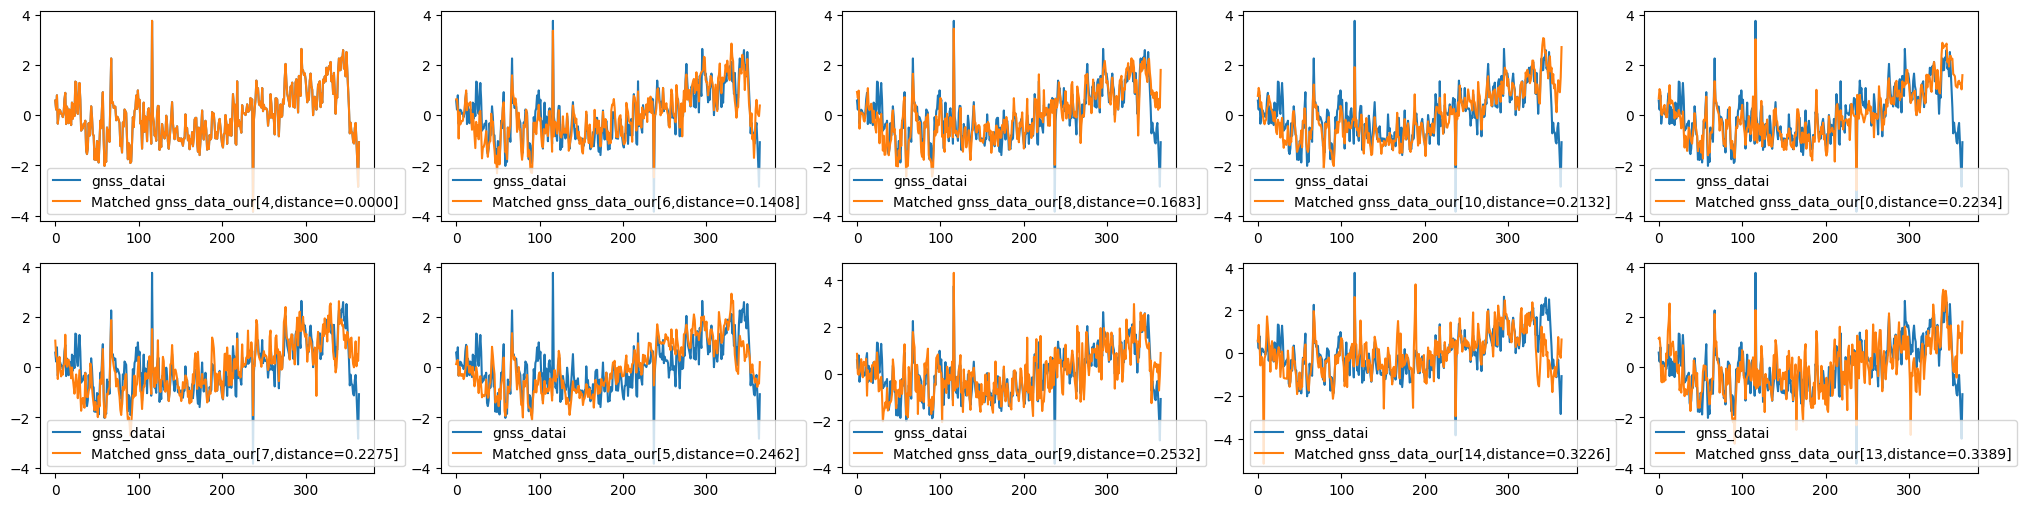

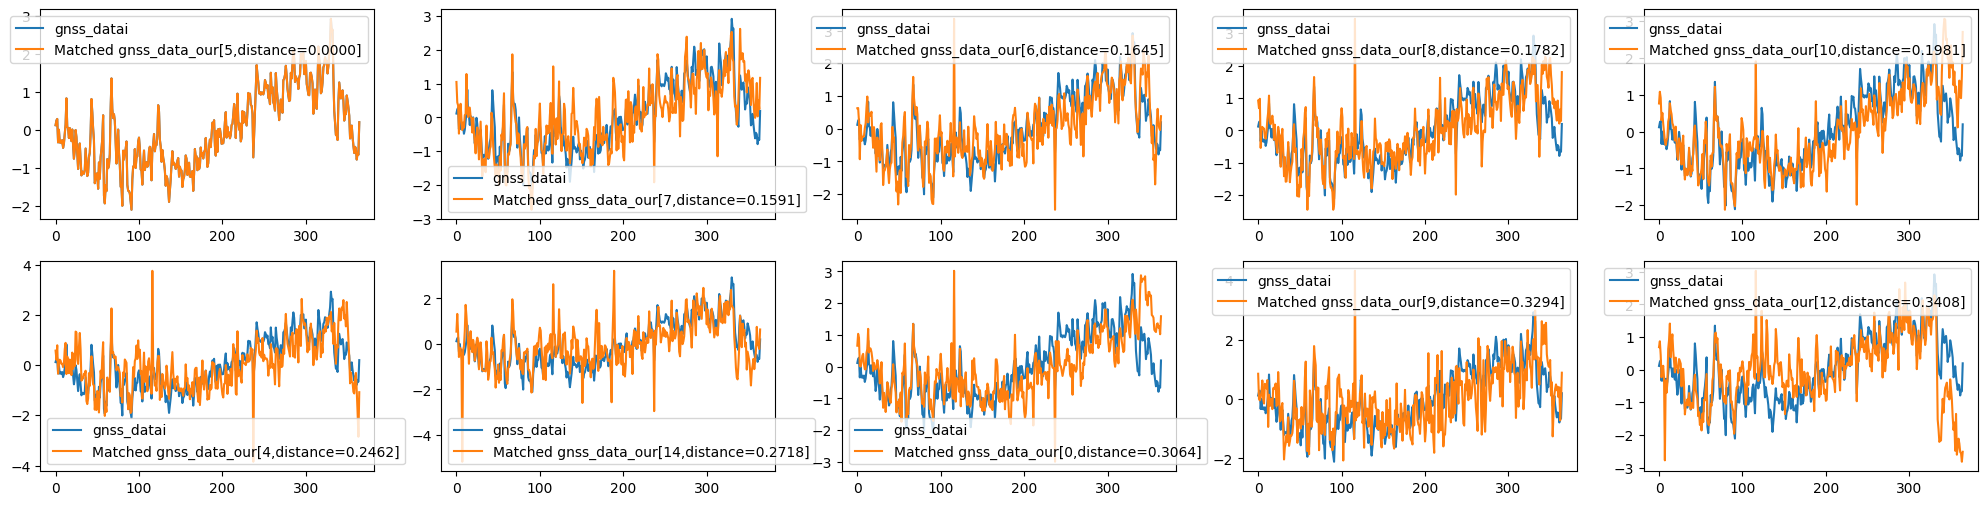

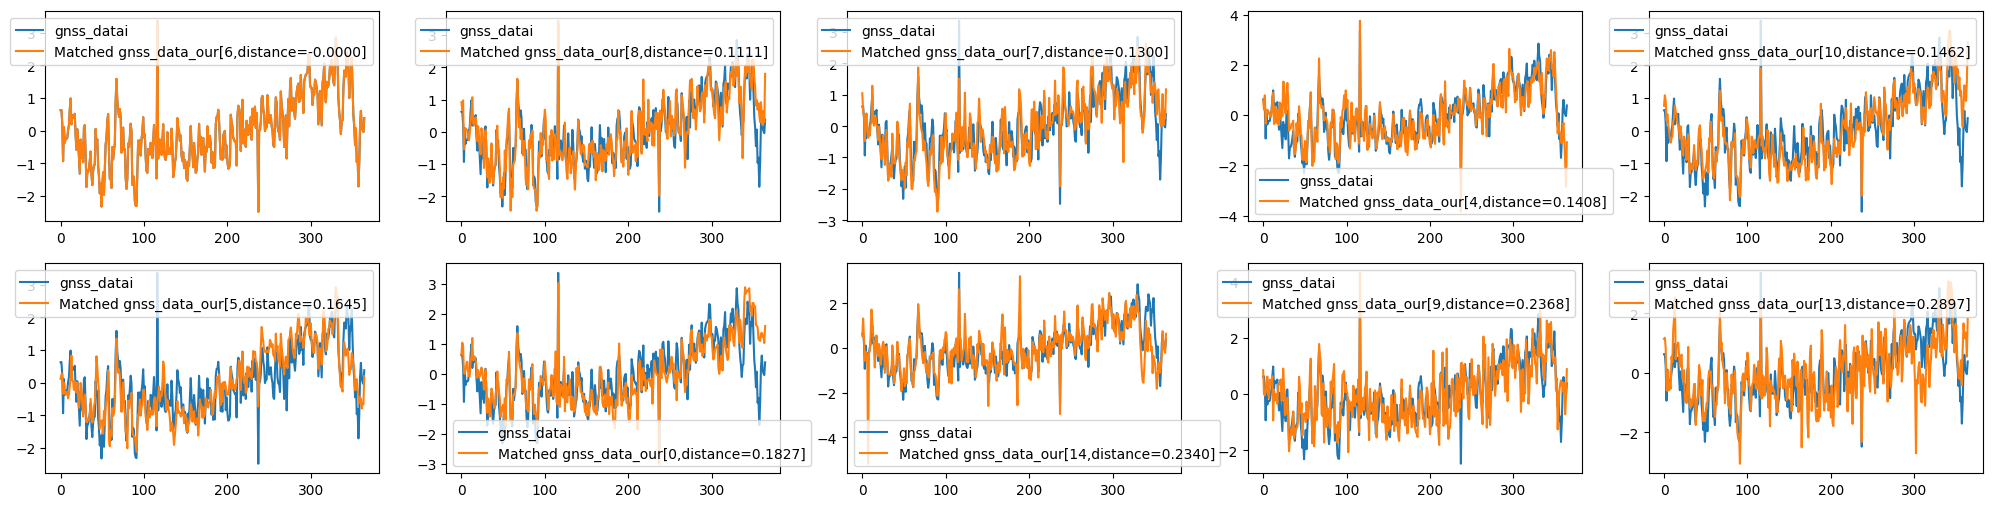

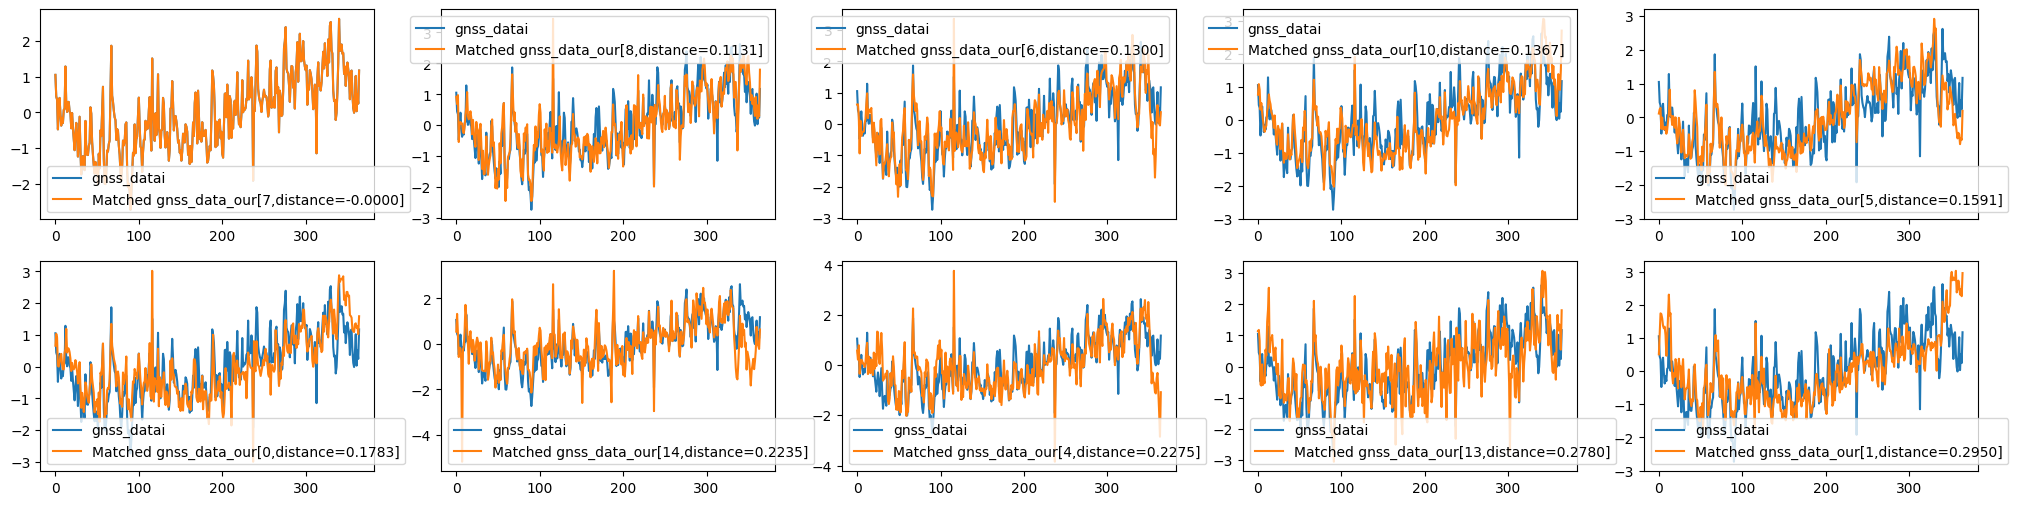

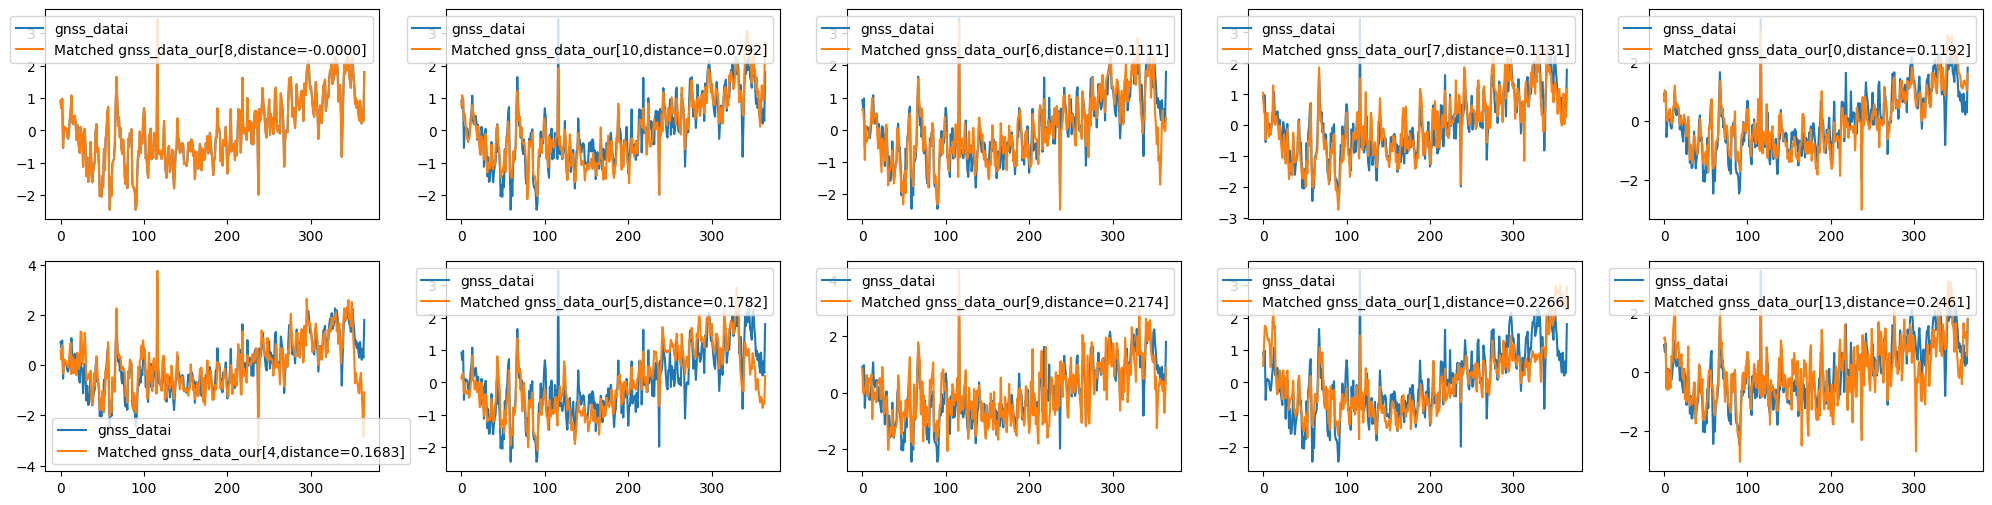

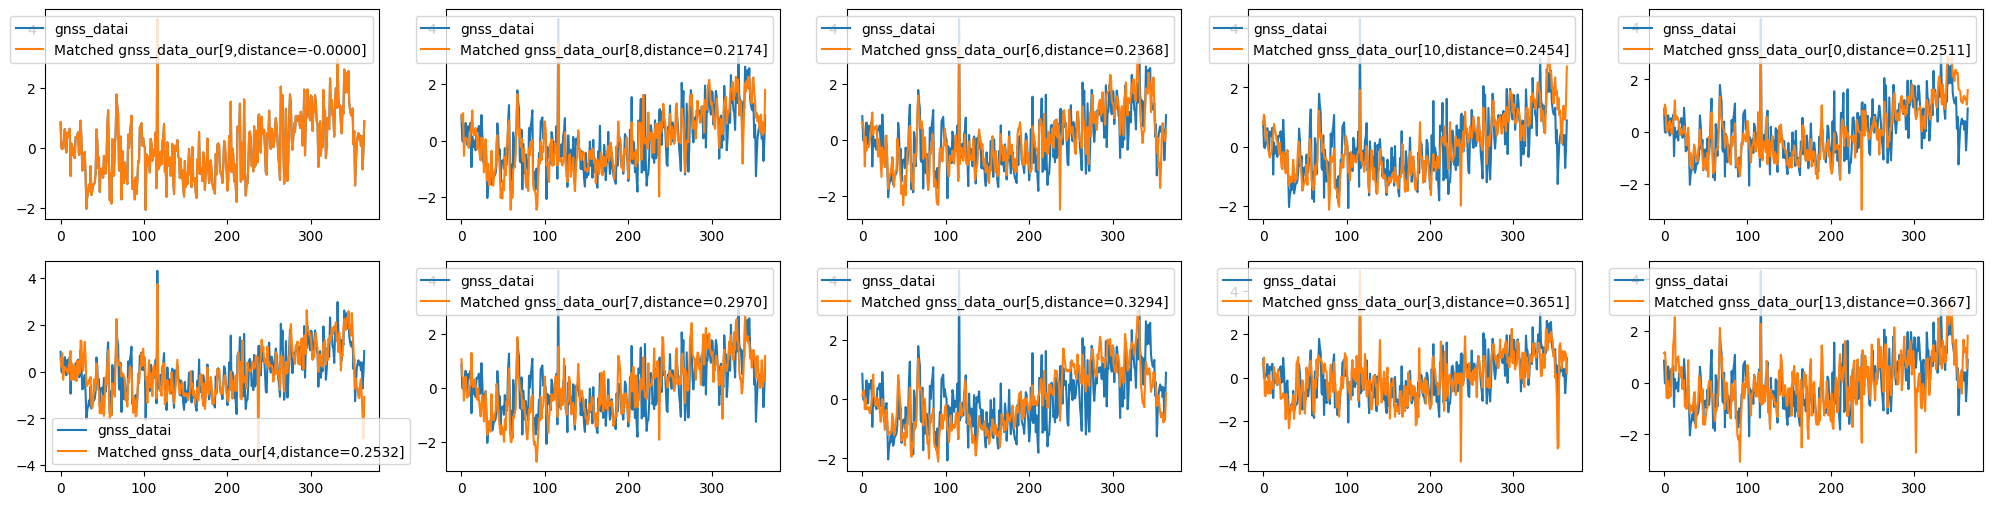

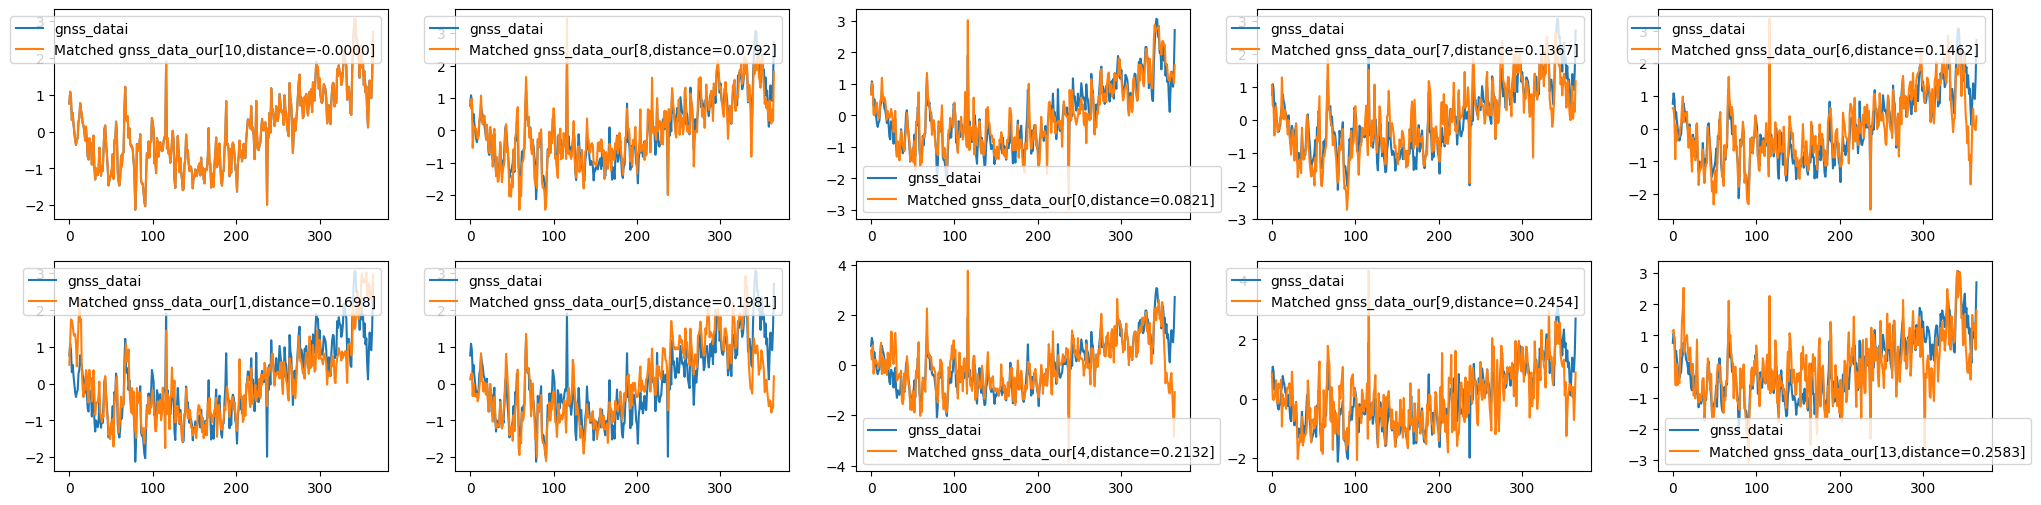

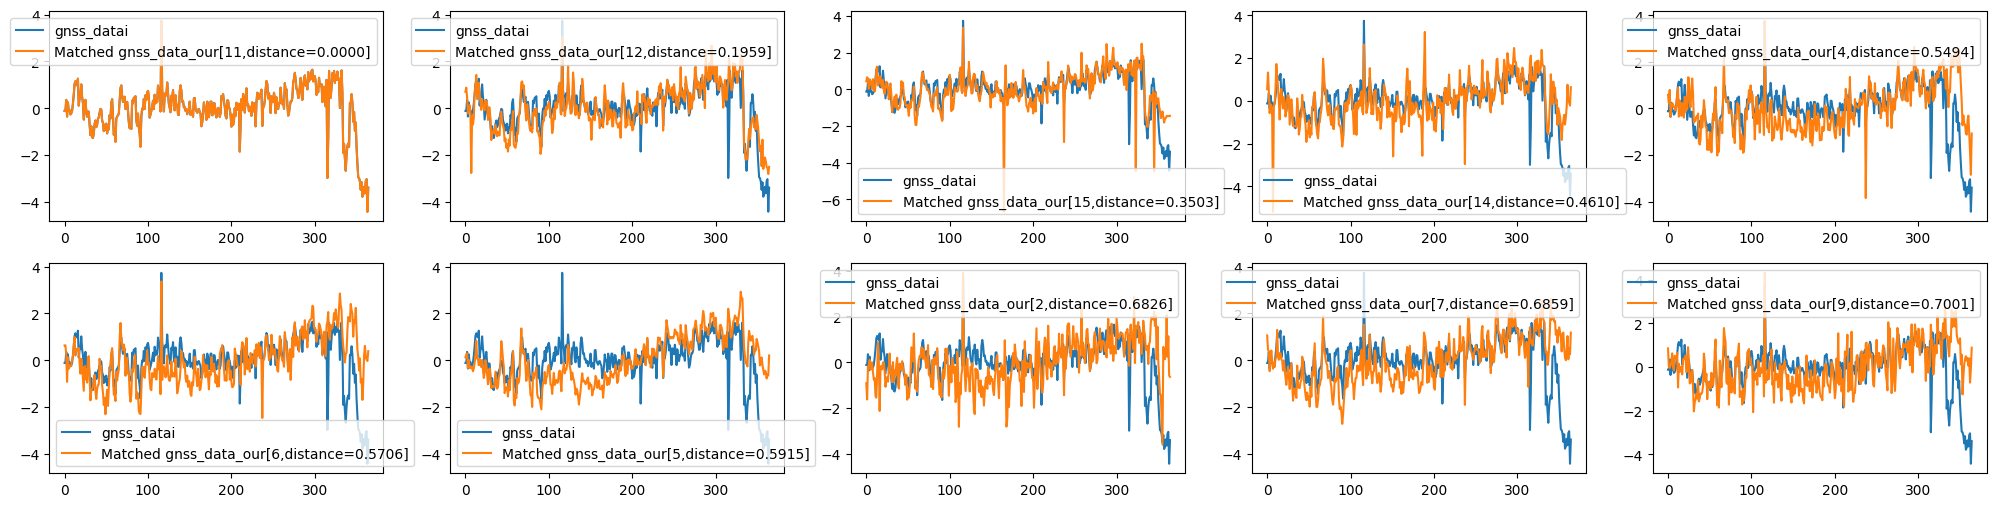

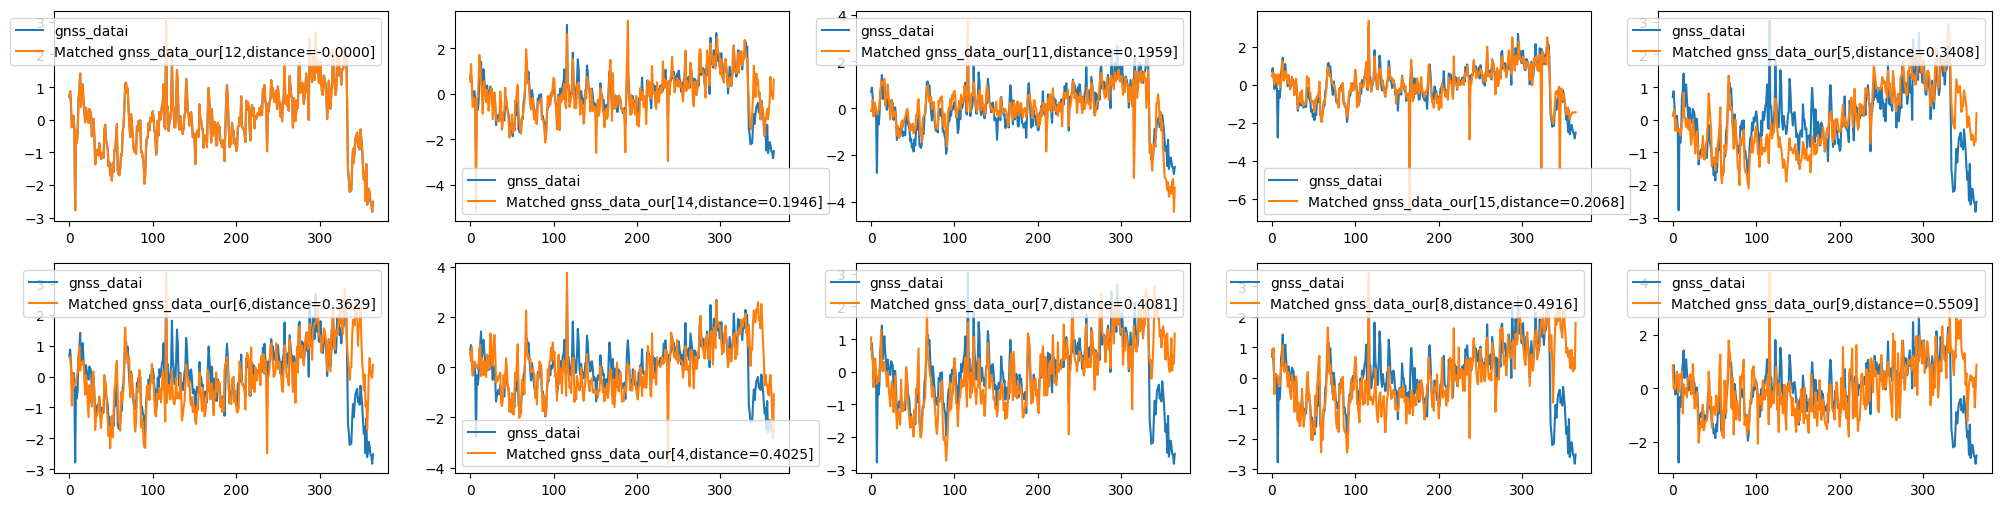

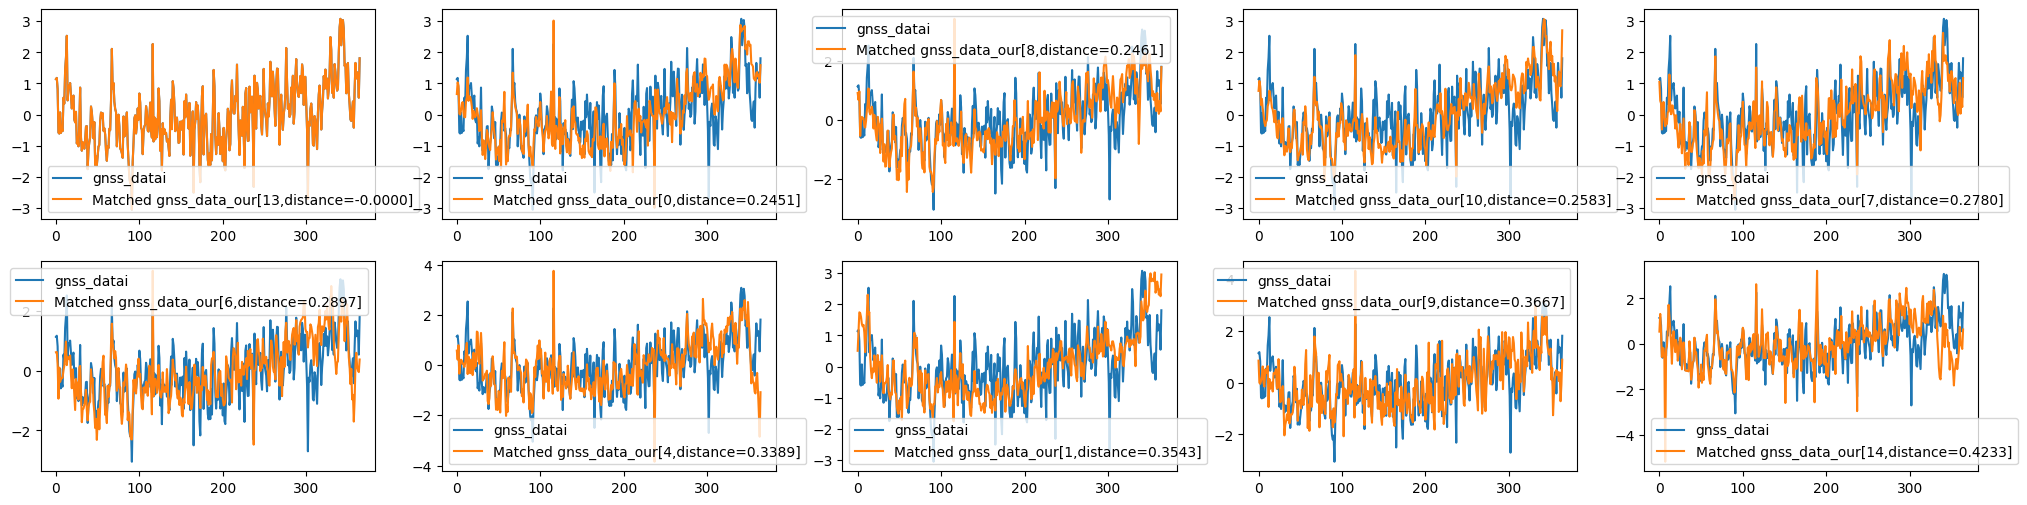

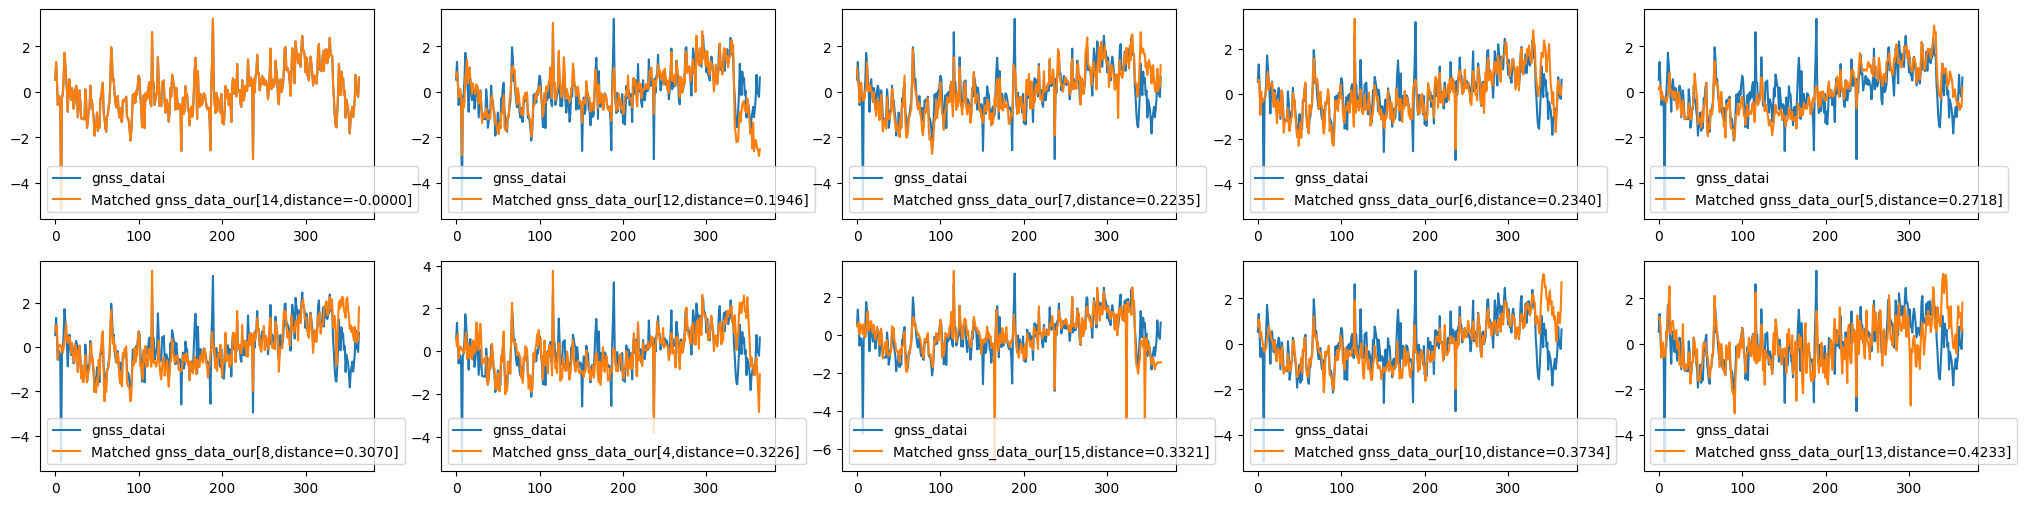

In [156]:
for i in range(15):
    gnss_datai = gnss_data[i]  # 获取第 i 个 GNSS 数据
    dot_product = np.sum(gnss_data * gnss_datai, axis=1)
    norm_our = np.sqrt(np.sum(np.square(gnss_data), axis=1))
    norm_i = np.sqrt(np.sum(gnss_datai**2))
    distances = 1 - (dot_product / (norm_our * norm_i))  # 1 - 余弦相似度
    index_all = np.argsort(distances)[0:10]  # 找到距离最小的索引
    # 可视化结果
    plt.figure(figsize=(25, 6))
    for i in range(len(index_all)):
        index = index_all[i]
        plt.subplot(2, 5, i + 1)
        plt.plot(gnss_datai, label="gnss_datai")
        plt.plot(gnss_data[index], label=f"Matched gnss_data_our[{index},distance={distances[index]:.4f}]")
        plt.legend()
    plt.show()

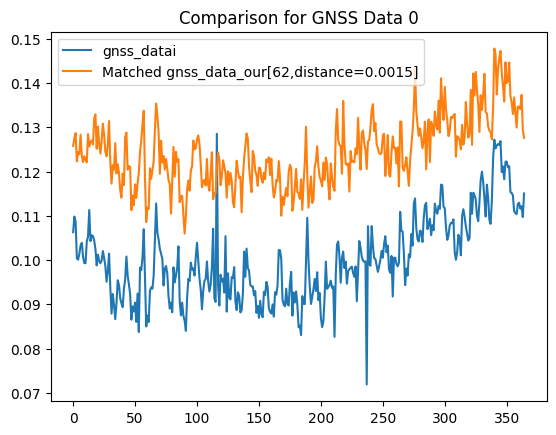

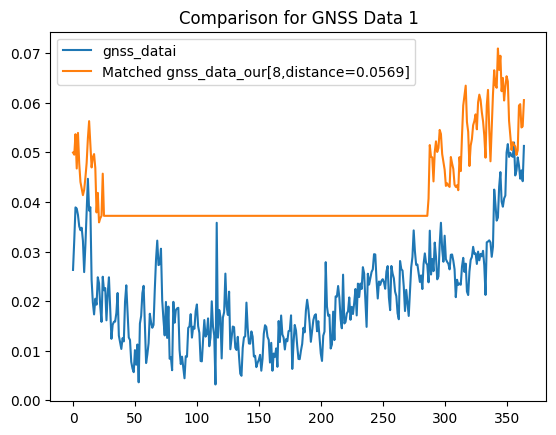

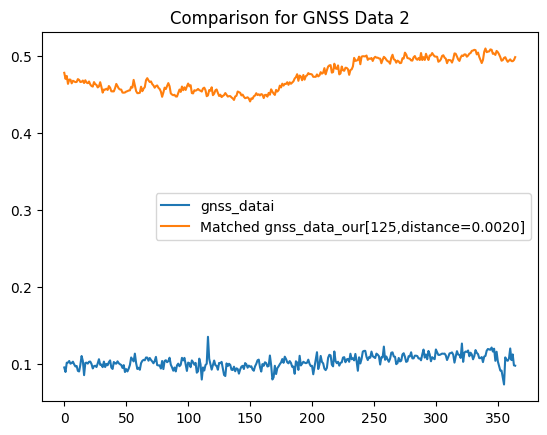

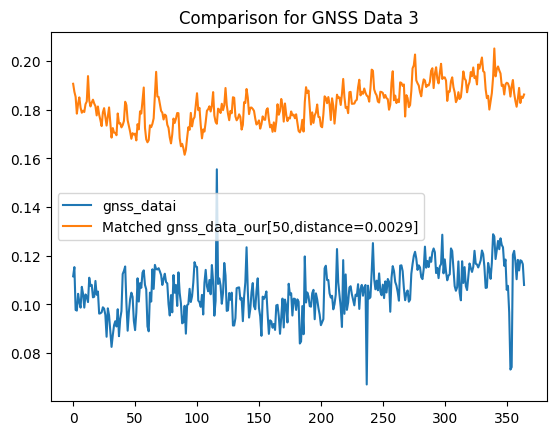

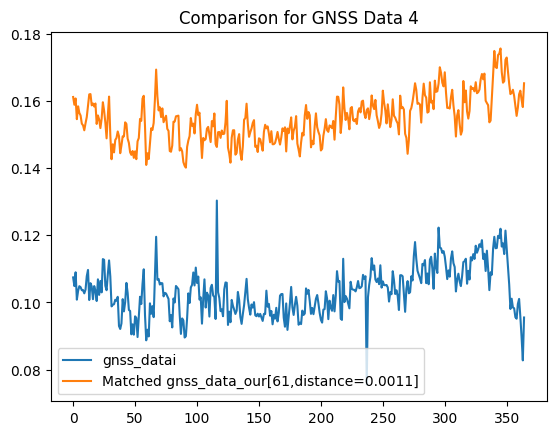

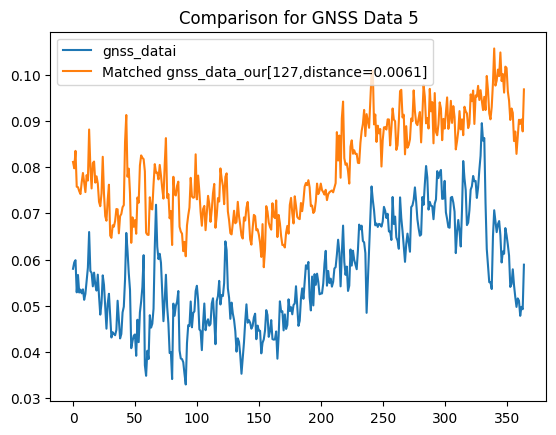

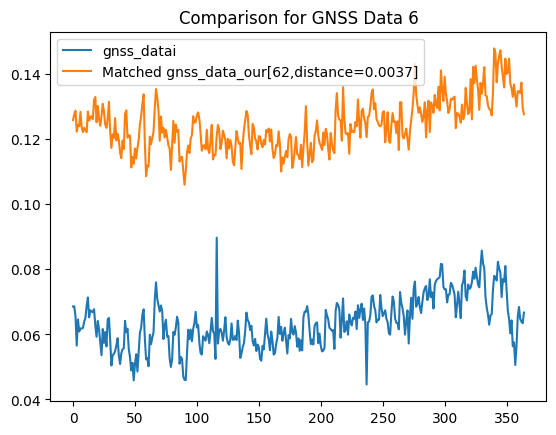

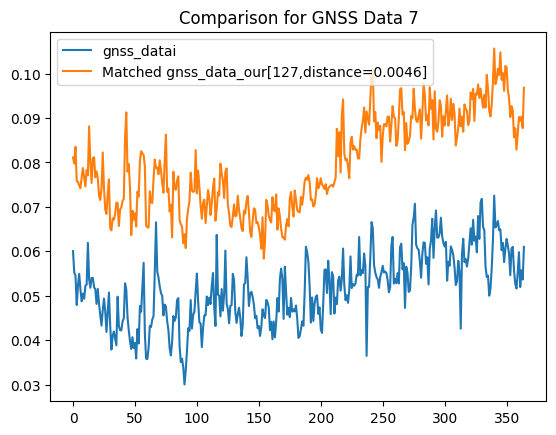

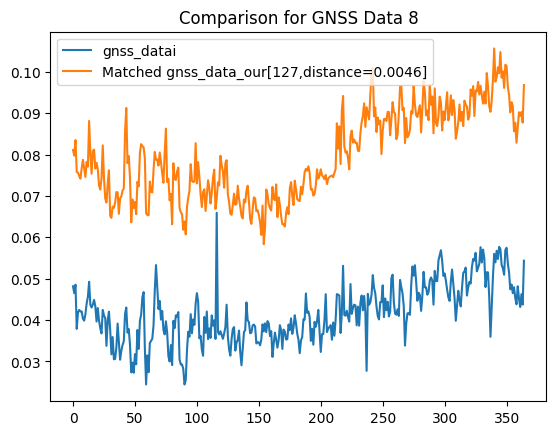

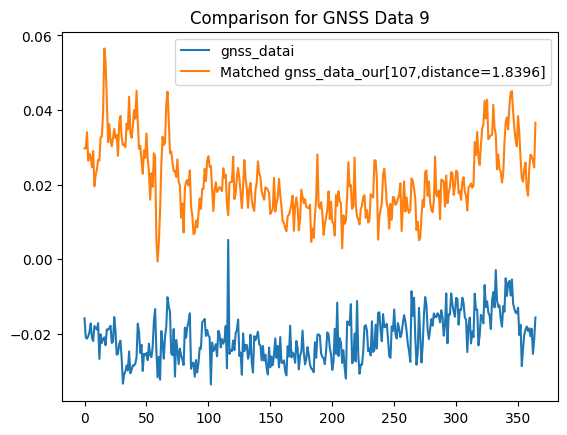

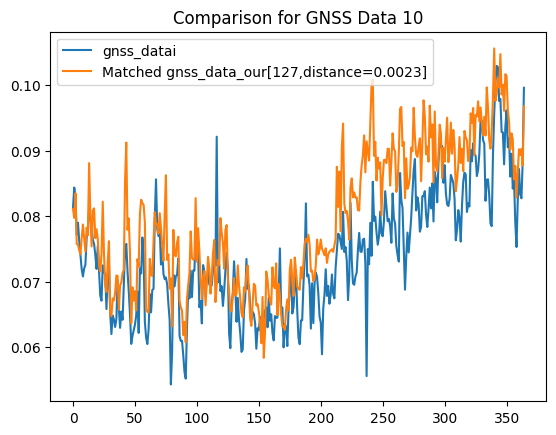

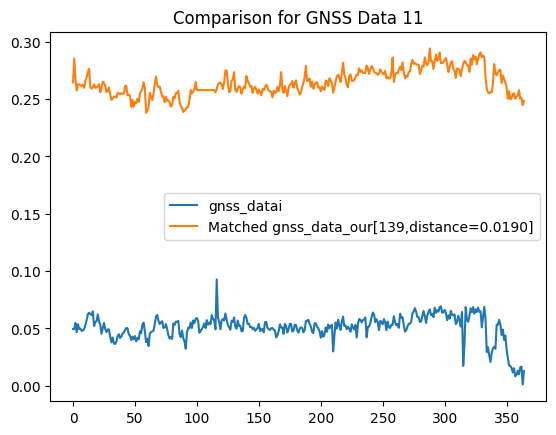

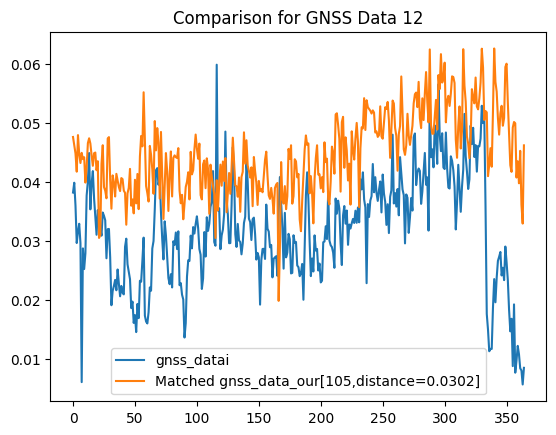

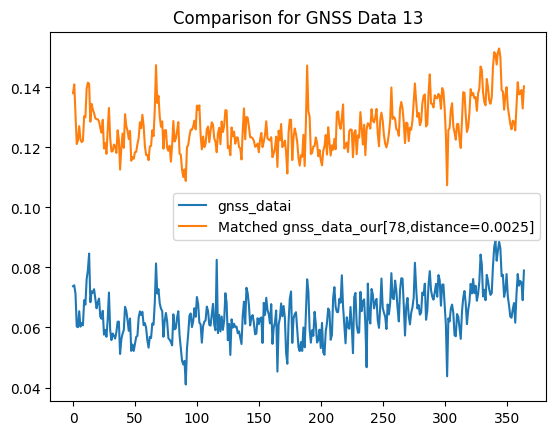

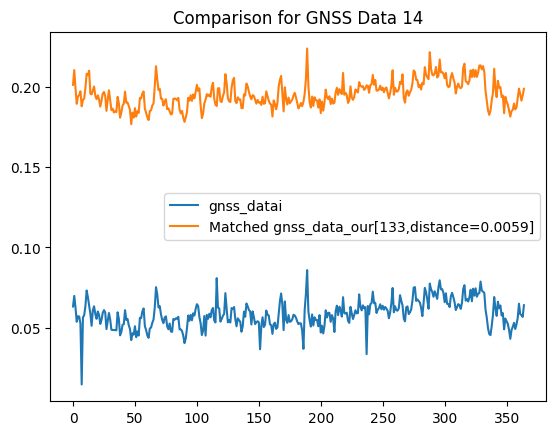

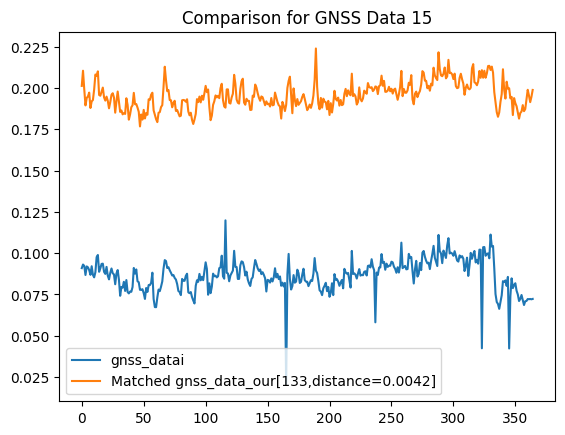

In [131]:
for i in range(16):
    gnss_datai = gnss_data[i]  # 获取第 i 个 GNSS 数据
    dot_product = np.sum(gnss_data_our * gnss_datai, axis=1)
    norm_our = np.sqrt(np.sum(np.square(gnss_data_our), axis=1))
    norm_i = np.sqrt(np.sum(gnss_datai**2))
    distances = 1 - (dot_product / (norm_our * norm_i))  # 1 - 余弦相似度
    index = np.argsort(distances)[0]  # 找到距离最小的索引
    
    # 可视化结果
    plt.figure()
    plt.plot(gnss_datai, label="gnss_datai")
    plt.plot(gnss_data_our[index], label=f"Matched gnss_data_our[{index},distance={distances[index]:.4f}]")
    plt.legend()
    plt.title(f"Comparison for GNSS Data {i}")
    plt.show()

In [4]:
def myLeakyRelu(x, leak, flag):
    """
    Apply LeakyReLU activation function.

    Args:
        x (ndarray): Input data.
        leak (float): Slope for negative values.
        flag (int): 1 for standard LeakyReLU, 2 for inverse LeakyReLU.

    Returns:
        ndarray: Activated output.
    """
    myleak = leak if flag == 1 else 1 / leak
    output = np.where(x >= 0, x, myleak * x)
    return output

In [5]:

def NN_transform(traindata, weights):
    """
    Transform data using a neural network structure.

    Args:
        traindata (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata.shape
    output = np.zeros((weights[-1].shape[1], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata[:, i]  # Input for the current timestep
        for weight in weights:
            curr_layer_nodes_value = np.dot(pre_layer_nodes_value, weight)
            # Apply activation function (tanh or LeakyReLU)
            curr_layer_nodes_value = np.tanh(curr_layer_nodes_value / 3.0)
            curr_layer_nodes_value = myLeakyRelu(curr_layer_nodes_value, leak=0.01, flag=1)
            pre_layer_nodes_value = curr_layer_nodes_value
        output[:, i] = curr_layer_nodes_value  # Store result for this timestep
    
    return output

In [6]:
def NN_transform_reverse(traindata_NN, weights):
    """
    Reverse transform using a neural network structure.

    Args:
        traindata_NN (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Reverse transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata_NN.shape
    output = np.zeros((weights[0].shape[0], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata_NN[:, i]
        for weight in reversed(weights):
            pre_layer_nodes_value = myLeakyRelu(np.dot(pre_layer_nodes_value, weight.T), leak=0.01, flag=1)
        output[:, i] = pre_layer_nodes_value
    
    return output

In [11]:
def weights_align1(weight_a, weight_b, weight_c, input_dimension):
    """
    Generate weights for the neural network.

    Args:
        weight_a, weight_b, weight_c (int): Number of nodes in each layer.
        input_dimension (int): Input dimension.

    Returns:
        tuple: (all_weights, reverse_all_weights), both are lists of weight matrices.
    """
    post_nodes_num = [weight_a, weight_b, weight_c]
    layer_nodes_num = [input_dimension] + post_nodes_num
    
    all_weights = []
    reverse_all_weights = []
    
    for l in range(1, len(layer_nodes_num)):
        weight_matrix = np.random.randn(layer_nodes_num[l - 1], layer_nodes_num[l])
        all_weights.append(weight_matrix)
        reverse_all_weights.append(np.linalg.pinv(weight_matrix))
    
    return all_weights, reverse_all_weights

In [12]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# 设置随机数种子
import random

GNSS_data = gnss_data_2019.values
# 初始化参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 57
sample_use = 365

altitude_matrix_databeihaidao1 = GNSS_data.T[:,:sample_use]

# 计算时间点
timepoint = sample_use - samples + 1

# 初始化变量
normal_sd_y = np.zeros((timepoint, 1))
normal_sd_original = np.zeros((stationnum, timepoint))
critical_sd_y = 0
ii = 0
good_ii = 0
reps = 0
nreps = 0


# 主循环，执行10000次迭代
while ii < 10000:
    ii += 1
    input_dimensions = stationnum

    # 获取权重矩阵
    all_weights, reverse_all_weights = weights_align1(weight_a, weight_b, weight_c, altitude_matrix_databeihaidao1.shape[0])

    # 样本的关键区域
    critical_zone = np.arange(sample_use - samples, sample_use)

    normal_start = 0

    # 内部循环，遍历所有可能的正常区域
    while normal_start + samples - 1 < sample_use:
        normal_start += 1
        normal_zone = np.arange(normal_start - 1, normal_start + samples - 1)
        myzone = [normal_zone]
        # 计算正常区域的标准差
        normal_sd_original[:, normal_start - 1] = np.std(altitude_matrix_databeihaidao1[:, myzone[0]], axis=1, ddof=0)
    
        for mys in range(1):
            UU = altitude_matrix_databeihaidao1[:, myzone[mys]]

            input_dimensions, time_points = UU.shape # 16, 11

            flat_y = np.zeros((time_points + embeddings_num - 1, 1))
            xx = UU
            noisestrength = 0  # 可以添加噪声
            xx_noise = xx + noisestrength * np.random.rand(*xx.shape)
            D = xx_noise.shape[0]  # 系统中的变量数量 16
            trainlength = time_points

            traindata = xx_noise[:, :trainlength]

            traindata_x_NN = NN_transform(traindata, all_weights)
            test_NN = traindata_x_NN #(5, 11)
            
            F_dimensions = traindata_x_NN.shape[0]

            # 求解权重矩阵A
            AA_rows = (trainlength - 1) * (embeddings_num - 1) + 1
            AA_cols = embeddings_num * F_dimensions

            AA = np.zeros((AA_rows, AA_cols)) #41, 25
            b = np.zeros((AA_rows, 1))

            for k in range(embeddings_num - 1):
                for t in range(1, trainlength):
                    row_idx = k * (trainlength - 1) + t - 1
                    AA[row_idx, k * F_dimensions: (k + 1) * F_dimensions] = traindata_x_NN[:, t]
                    AA[row_idx, (k + 1) * F_dimensions: (k + 2) * F_dimensions] = -traindata_x_NN[:, t - 1]

            AA[(trainlength - 1) * (embeddings_num - 1), 0:F_dimensions] = traindata_x_NN[:, 1]
            b[(trainlength - 1) * (embeddings_num - 1), 0] = traindata_x_NN[0, 0]

            # 求解线性方程 AA * flat_A = b

            flat_A, residuals, rank, s_vals = np.linalg.lstsq(AA, b, rcond=None)

            flat_A = flat_A.flatten()

            weight_A = np.zeros((embeddings_num, F_dimensions))
            for i in range(embeddings_num):
                weight_A[i, :] = flat_A[i * F_dimensions: (i + 1) * F_dimensions]

            # 计算Y
            Y = np.dot(weight_A, traindata_x_NN)  # Y的大小为 (embeddings_num, trainlength)

            # 计算权重矩阵B
            B = np.dot(traindata_x_NN, np.linalg.pinv(Y))
            X_real = xx_noise[:, :trainlength]
            II = np.dot(weight_A, B)

            for t in range(trainlength):
                min_val = min(t + 1, embeddings_num)
                for j in range(min_val):
                    m = t - j
                    l = j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= min_val

            for t in range(trainlength, trainlength + embeddings_num - 1):
                max_j = embeddings_num - (t - trainlength)
                for j in range(max_j):
                    m = trainlength - j - 1
                    l = t - trainlength + j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= max_j

            # 计算标准差
            if 'sd1' not in locals():
                sd1 = np.zeros((1, flat_y.shape[0]))
                test_flat_y = np.zeros((1, flat_y.shape[0]))
            sd1[mys, :] = np.std(flat_y, axis=0, ddof=0)
            test_flat_y[mys, :] = flat_y.flatten()

        normal_sd_y[normal_start - 1, 0] += np.std(test_flat_y[0, :], ddof=0)
        reps += 1
    # 打印进度
    if ii % 100 == 0:
        print(ii)

# 计算平均标准差
normal_sd_y = normal_sd_y / ii

# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.show()

KeyboardInterrupt: 

In [9]:
import numpy as np

def NN_F2(weight_a, weight_b, weight_c, weight_d, weight_e, traindata):
    """
    Implements the NN_F2 function to simulate a simple feedforward neural network.

    Parameters:
    - weight_a, weight_b, weight_c, weight_d, weight_e: Weights specifying the number of nodes in each layer.
    - traindata: Input data matrix of shape (input_dimension, trainlength).

    Returns:
    - output: Output of the neural network of shape (layer_nodes_num[-1], trainlength).
    """
    layer_nodes_num = [weight_a, weight_b, weight_c, weight_d, weight_e]
    input_dimension, trainlength = traindata.shape
    pre_layer_nodes_num = input_dimension

    # Initialize weights for all layers
    all_weights = {}
    for l in range(len(layer_nodes_num)):
        curr_layer_nodes_num = layer_nodes_num[l]
        for it in range(curr_layer_nodes_num):
            curr_node_input_weight = np.random.randn(pre_layer_nodes_num)
            all_weights[(l, it)] = curr_node_input_weight
        pre_layer_nodes_num = curr_layer_nodes_num

    # Forward pass through the network
    output = np.zeros((layer_nodes_num[-1], trainlength))
    for i in range(trainlength):
        pre_layer_nodes_num = input_dimension
        pre_layer_nodes_value = traindata[:, i]  # Input for the current sample

        for l in range(len(layer_nodes_num)):
            curr_layer_nodes_num = layer_nodes_num[l]
            curr_layer_nodes_value = []
            for it in range(curr_layer_nodes_num):
                curr_node_input_weight = all_weights[(l, it)]
                xx = np.sum(pre_layer_nodes_value * curr_node_input_weight)
                curr_layer_nodes_value.append(np.tanh(xx / 2.5))
            pre_layer_nodes_value = np.array(curr_layer_nodes_value).reshape(-1)
            pre_layer_nodes_num = curr_layer_nodes_num

        output[:, i] = pre_layer_nodes_value

    return output

In [10]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np
from multiprocessing import Pool, cpu_count

# 假设 GNSS_data 和 sample_use 已经定义
altitude_matrix_data = GNSS_data.T[:, :sample_use]

window_len = 4
newdata = np.zeros((altitude_matrix_data.shape[0],
                    altitude_matrix_data.shape[1] - window_len + 1))

for i in range(newdata.shape[1]):
    newdata[:, i] = np.mean(altitude_matrix_data[:, i:i + window_len], axis=1)

# 初始化参数
predict_len = 4
trainlength = 9
noisestrength = 0
X = altitude_matrix_data

weight_a = 400
weight_b = 300
weight_c = 200
weight_d = 100
weight_e = 100

# 定义目标站点
aim_station = list(range(1, stationnum + 1))

# 设置随机种子以保证可重复性
np.random.seed(42)


# 定义处理单个站点的函数
def process_station(args):
    tt, jd = args
    pcc_y = []
    Loss_y = []
    rmse_y = []
    ii = 0

    while X.shape[1] - ii >= predict_len + trainlength:
        ii += 1
        xx = X[:, ii:]
        traindata = xx[:, :trainlength]
        k = 30
        real_y = xx[jd - 1, :]
        all_real_y = X[jd - 1, :]

        traindata_y = real_y[:trainlength]

        # 生成 NN_train 数据
        traindata_x_NN = np.zeros((weight_e, trainlength))

        for i in range(trainlength):
            traindata_x_NN[:, i] = NN_F2(weight_a, weight_b, weight_c, weight_d, weight_e,
                                         traindata[:, i].reshape(-1, 1)).flatten()

        # 初始化权重矩阵
        w_flag = np.zeros(traindata_x_NN.shape[0])
        B_w = np.zeros((traindata_x_NN.shape[0], predict_len))

        # 计算系数矩阵 B
        for _ in range(1000):
            available_indices = np.setdiff1d(range(traindata_x_NN.shape[0]), [jd - 1])
            if len(available_indices) < k - 1:
                random_idx = available_indices
            else:
                random_idx = np.random.choice(available_indices, k - 1, replace=False)
            random_idx = np.sort(np.append(jd - 1, random_idx))
            traindata_x = traindata_x_NN[random_idx, :trainlength]

            for i, idx in enumerate(random_idx):
                b = traindata_x[i, :(trainlength - predict_len + 1)]
                A = np.array([traindata_y[j:j + predict_len] for j in range(trainlength - predict_len + 1)])
                w = np.linalg.lstsq(A, b, rcond=None)[0]
                B_w[idx, :] = (B_w[idx, :] + w + w * (1 - w_flag[idx])) / 2
                w_flag[idx] = 1

        # 预测逻辑
        super_bb = []
        super_AA = []

        for i in range(traindata_x_NN.shape[0]):
            bb = []
            AA = np.zeros((predict_len - 1, predict_len - 1))

            for j in range(trainlength - predict_len + 1, trainlength):
                col_known_y_num = trainlength - j
                bb_val = traindata_x_NN[i, j]

                for r in range(col_known_y_num):
                    bb_val -= B_w[i, r] * traindata_y[trainlength - col_known_y_num + r]

                bb.append(bb_val)
                AA[j - (trainlength - predict_len + 1), :(predict_len - col_known_y_num)] = B_w[i, col_known_y_num:predict_len]

            super_bb.extend(bb)
            super_AA.extend(AA)

        super_bb = np.array(super_bb)
        super_AA = np.array(super_AA)

        # 预测结果
        pred_y = np.linalg.lstsq(super_AA, super_bb, rcond=None)[0]
        myreal = real_y[trainlength:trainlength + predict_len - 1]

        pcc = pearsonr(pred_y, myreal)[0]
        pcc_y.append(pcc)
        Loss = np.sqrt(mean_squared_error(pred_y, myreal)) / np.std(myreal)
        rmse = np.sqrt(mean_squared_error(pred_y, myreal))
        Loss_y.append(Loss)
        rmse_y.append(rmse)

    return pcc_y, Loss_y, rmse_y

# 并行处理
if __name__ == '__main__':
    from functools import partial

    # 将 X 传递给子进程
    global X

    # 准备参数列表
    args_list = [(tt, jd) for tt, jd in enumerate(aim_station)]

    # 使用所有可用的 CPU 核心
    num_cores = cpu_count()

    # 创建进程池并并行计算
    with Pool(processes=num_cores) as pool:
        results = pool.map(process_station, args_list)

    # 收集结果
    pcc_station = []
    loss_station = []
    rmse_station = []

    for res in results:
        pcc_y, Loss_y, rmse_y = res
        pcc_station.append(pcc_y)
        loss_station.append(Loss_y)
        rmse_station.append(rmse_y)

In [11]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import ttest_1samp

rmse_station_all_use = np.array(rmse_station)

combined_sd_y_sc1 = combined_sd_y_South_central_Alaska

# 准备 ydata
ydata = np.hstack((np.zeros(sample_use - combined_sd_y_sc1.size), combined_sd_y_sc1.flatten()))

# 准备 rmse_stationall
zeros_to_prepend = np.zeros((stationnum, sample_use - rmse_station_all_use.shape[1]))
rmse_station_all_predi_4 = np.hstack((zeros_to_prepend, rmse_station_all_use))
rmse_stationall = rmse_station_all_predi_4

# 初始化变量
loss_p = np.zeros(rmse_stationall.shape)
windows = 12

# 主循环
for j in range(rmse_stationall.shape[0]):
    now_rmse_station = rmse_stationall[j, :]
    for i in range(windows, len(now_rmse_station)):

        long_pic = now_rmse_station[i - windows:i]
        now_num = now_rmse_station[i]
        # 执行 t 检验
        t_stat, p_value = ttest_1samp(long_pic, now_num)      
        loss_p[j, i] = p_value

In [12]:
YYY = np.zeros(len(ydata))
for i in range(len(ydata)):
    YY_pic = ydata[10:14]  # MATLAB 索引 11:14 对应 Python 的 10:14
    YY_num = ydata[i]
    t_stat, p_value = ttest_1samp(YY_pic, YY_num)
    if p_value < 0.01:
        YYY[i] = 1
    else:
        YYY[i] = 0

# 收集 YYY > 0 的索引
mark1 = np.where(YYY > 0)[0]

In [13]:
# 假设已经导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

earthquake_matrix = earthquake_data_2019.values
Y2 = earthquake_matrix

# 创建日期向量
t_start = start_time
t_long = t_start
t1 = np.array([t_long + timedelta(days=i) for i in range(len(ydata))])  # ydata 的日期

t_es = np.array([t_long + timedelta(days=i) for i in range(len(Y2))])    # 地震事件的日期

# 计算 mmm
number = rmse_stationall.shape[0]
mmm = np.sum(loss_p[:number, :], axis=0) / number
mmm[mmm != 0] = 1 / mmm[mmm != 0]

# 找出 mmm > 20 的索引，得到 mark3
mark3 = np.where(mmm > 20)[0]

# 计算 mark
mark = []
for m in mark1:
    a = max(0, m - 14)
    b = min(len(ydata)-1, m)
    c = min(len(ydata)-1, m + 14)
    for mk in mark3:
        if a <= mk <= b:
            mark.append(m)
            break
        elif b < mk <= c:
            mark.append(mk)
            break
mark = np.unique(mark)

# 创建 single 数组
single = np.zeros(len(ydata))
single[mark] = 1

# 初始化变量
starday = 0
earthquake = 0
acuur_single = np.zeros(len(single))
accur_earthqu = []

for i in range(starday, len(Y2)):
    if Y2[i] != 0:
        earthquake += 1
        a = max(0, i - 14)
        b = min(len(ydata)-1, i)
        if np.any(single[a:b+1] == 1):
            accur_earthqu.append(i)
            acuur_single[np.where(single[a:b+1] == 1)[0] + a] = 1
accur_earthqu = np.unique(accur_earthqu)

# 计算 acuur_mark
acuur_mark = np.where(acuur_single == 1)[0]

# 计算 TP 和 FN
TP = len(accur_earthqu)
FN = earthquake - TP

# 计算 erro_single
erro_single = single.copy()
for mmm in accur_earthqu:
    a = max(0, mmm - 14)
    b = min(len(ydata)-1, mmm)
    erro_single[a:b+1][single[a:b+1] == 1] = 0

# 计算 erro_mark
erro_mark = np.where(erro_single == 1)[0]

# 计算 FP 和 TN
FP = np.sum(erro_single[starday:])
TN = len(ydata[starday:]) - earthquake - FP

# 计算评估指标
Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
Specificity = TN / (FP + TN) if (FP + TN) > 0 else 0
Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

# 调整 acuur_single 和 erro_single 以便绘图
acuur_single[acuur_single != 0] = 4
erro_single[erro_single != 0] = 4



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


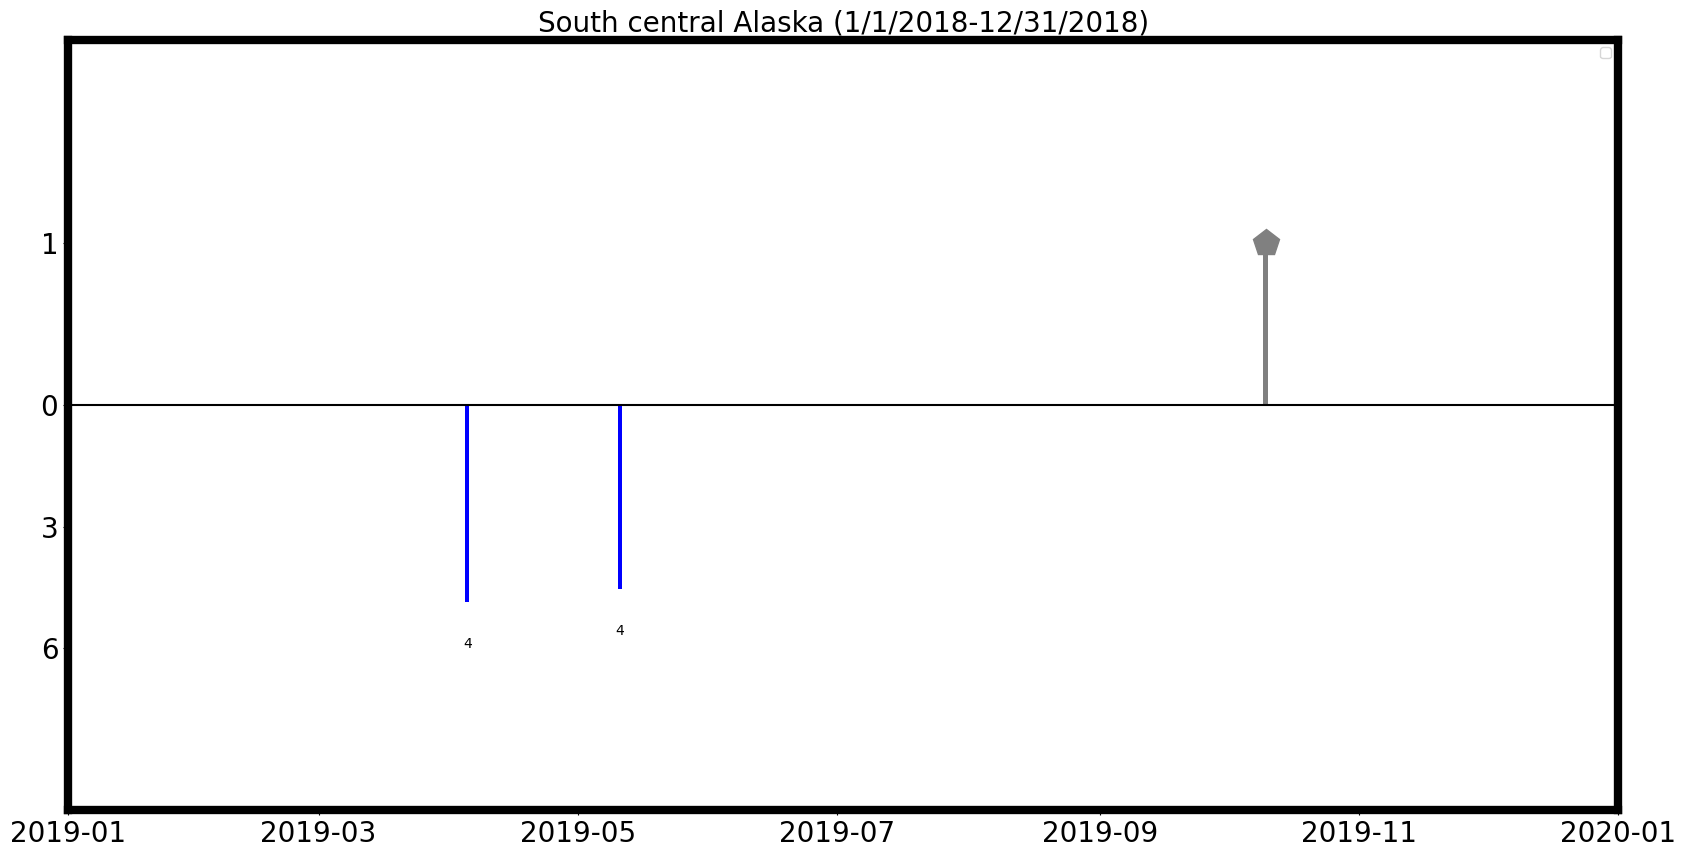

TP: 0
FN: 2
FP: 1.0
TN: 362.0
Precision: 0.0
TPR (Sensitivity): 0.0
FPR: 0.0027548209366391185
Specificity: 0.9972451790633609
Accuracy: 0.9917808219178083
Error Rate: 0.00821917808219178


In [14]:
# 绘制原始图形，并添加 mark1 和 mark3
plt.figure(figsize=(20, 10))
demo = np.zeros(len(ydata))  # 确保 demo 的长度与 ydata 一致
plt.plot(t1, demo, color='k')

# 绘制 acuur_single
plt.bar(t1[starday:], acuur_single[starday:], color='r', width=1)

# 设置图形属性
plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([-6, -3, 0, 4], ['6', '3', '0', '1'])
plt.gca().spines['top'].set_linewidth(6)
plt.gca().spines['right'].set_linewidth(6)
plt.gca().spines['bottom'].set_linewidth(6)
plt.gca().spines['left'].set_linewidth(6)

# 标题
plt.title('South central Alaska (1/1/2018-12/31/2018)', fontsize=20)

# 绘制 erro_single
plt.bar(t1[starday:], erro_single[starday:], color=[0.5, 0.5, 0.5], width=1)

# 绘制 erro_mark 点
for idx in erro_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor=[0.5, 0.5, 0.5], markeredgecolor=[0.5, 0.5, 0.5], linewidth=2)

# 准备 Y4 以便绘制地震
Y4 = -Y2

# 添加地震的文本标签
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)

# 绘制地震
plt.bar(t_es[starday:], Y4[starday:].flatten(), color='b', width=1)

# 绘制 acuur_mark 点
for idx in acuur_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)


# 设置坐标轴范围
plt.xlim([datetime(2019, 1, 1), datetime(2020, 1, 1)])
plt.ylim([-10, 9])

# 添加图例
plt.legend()

# 显示图形
plt.show()


# 准备 AAAA
AAAA = [TP, FN, FP, TN, Precision, TPR, FPR, Specificity, Accuracy, error]
warning_effect = AAAA

# 输出结果
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


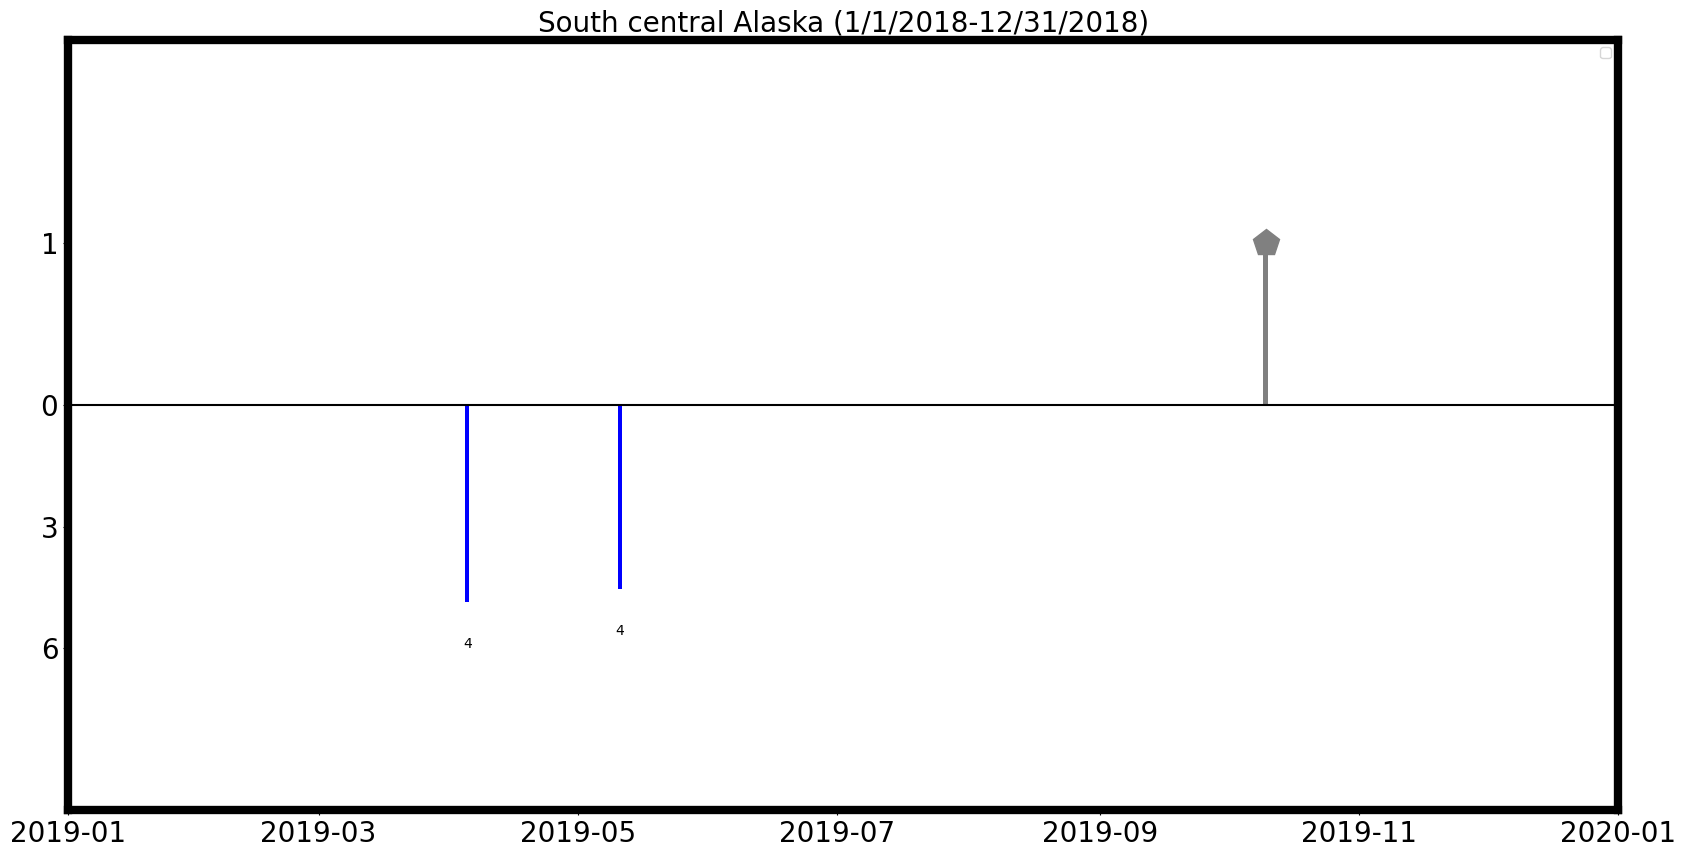

TP: 0
FN: 2
FP: 1.0
TN: 362.0
Precision: 0.0
TPR (Sensitivity): 0.0
FPR: 0.0027548209366391185
Specificity: 0.9972451790633609
Accuracy: 0.9917808219178083
Error Rate: 0.00821917808219178


In [15]:
# 绘制原始图形，并添加 mark1 和 mark3
plt.figure(figsize=(20, 10))
demo = np.zeros(len(ydata))  # 确保 demo 的长度与 ydata 一致
plt.plot(t1, demo, color='k')

# 绘制 acuur_single
plt.bar(t1[starday:], acuur_single[starday:], color='r', width=1)

# 设置图形属性
plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([-6, -3, 0, 4], ['6', '3', '0', '1'])
plt.gca().spines['top'].set_linewidth(6)
plt.gca().spines['right'].set_linewidth(6)
plt.gca().spines['bottom'].set_linewidth(6)
plt.gca().spines['left'].set_linewidth(6)

# 标题
plt.title('South central Alaska (1/1/2018-12/31/2018)', fontsize=20)

# 绘制 erro_single
plt.bar(t1[starday:], erro_single[starday:], color=[0.5, 0.5, 0.5], width=1)

# 绘制 erro_mark 点
for idx in erro_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor=[0.5, 0.5, 0.5], markeredgecolor=[0.5, 0.5, 0.5], linewidth=2)

# 准备 Y4 以便绘制地震
Y4 = -Y2

# 添加地震的文本标签
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)

# 绘制地震
plt.bar(t_es[starday:], Y4[starday:].flatten(), color='b', width=1)

# 绘制 acuur_mark 点
for idx in acuur_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)


# 设置坐标轴范围
plt.xlim([datetime(2019, 1, 1), datetime(2020, 1, 1)])
plt.ylim([-10, 9])

# 添加图例
plt.legend()

# 显示图形
plt.show()


# 准备 AAAA
AAAA = [TP, FN, FP, TN, Precision, TPR, FPR, Specificity, Accuracy, error]
warning_effect = AAAA

# 输出结果
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)